In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
np.set_printoptions(precision=3,suppress=True)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# --- DATA LOADING (online) + OFFLINE FALLBACK (synthetic) ---
# Ten notebook oryginalnie pobiera Auto MPG z UCI. W środowiskach bez internetu pojawia się błąd "brak źródła".
# Poniżej jest bezpieczny fallback: jeśli pobranie się nie uda, generujemy syntetyczny zbiór o podobnej strukturze.

import numpy as np
import pandas as pd

def make_synthetic_auto_mpg(n: int = 398, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    # Zmienne dyskretne
    cylinders = rng.choice([3, 4, 5, 6, 8], size=n, p=[0.02, 0.5, 0.03, 0.25, 0.20])
    model_year = rng.integers(70, 83, size=n)  # 70..82
    origin = rng.choice(["USA", "Europe", "Japan"], size=n, p=[0.62, 0.18, 0.20])

    # Displacement rośnie z cylindrami
    displacement = (
        cylinders * rng.normal(35, 6, size=n)
        + rng.normal(40, 25, size=n)
    )
    displacement = np.clip(displacement, 60, 460)

    # Horsepower zależny od displacement i cyl
    horsepower = (
        0.35 * displacement
        + 6 * (cylinders - 4)
        + rng.normal(0, 18, size=n)
    )
    horsepower = np.clip(horsepower, 45, 240)

    # Weight zależny od displacement i origin
    origin_weight_shift = np.select(
        [origin == "USA", origin == "Europe", origin == "Japan"],
        [250, -120, -80],
        default=0
    )
    weight = (
        8.5 * displacement
        + origin_weight_shift
        + rng.normal(0, 250, size=n)
        + 100 * (cylinders - 4)
    )
    weight = np.clip(weight, 1500, 5200)

    # Acceleration: większa masa = zwykle gorsze przyspieszenie (większy czas)
    acceleration = (
        22 - 0.0018 * weight + rng.normal(0, 1.2, size=n)
    )
    acceleration = np.clip(acceleration, 8, 25)

    # MPG: spada z masą/horsepower/displacement, rośnie z rokiem modelowym (postęp technologiczny)
    origin_eff = np.select(
        [origin == "USA", origin == "Europe", origin == "Japan"],
        [0.0, 2.2, 2.8],
        default=0.0
    )
    mpg = (
        58
        - 0.0048 * weight
        - 0.045 * horsepower
        - 0.010 * displacement
        + 0.55 * (model_year - 70)
        + origin_eff
        + rng.normal(0, 2.2, size=n)
    )
    mpg = np.clip(mpg, 8, 50)

    df = pd.DataFrame({
        "MPG": mpg.round(2),
        "Cylinders": cylinders.astype(int),
        "Displacement": displacement.round(1),
        "Horsepower": horsepower.round(1),
        "Weight": weight.round(1),
        "Acceleration": acceleration.round(2),
        "Model Year": model_year.astype(int),
        "Origin": origin
    })
    return df

def load_auto_mpg() -> pd.DataFrame:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    column_names = ["MPG","Cylinders","Displacement","Horsepower","Weight","Acceleration","Model Year","Origin"]

    try:
        raw = pd.read_csv(
            url,
            names=column_names,
            na_values="?",
            comment="\t",
            sep=" ",
            skipinitialspace=True,
        )
        ds = raw.copy().dropna()
        # origin w oryginale jest kodem 1/2/3
        if ds["Origin"].dtype != object:
            ds["Origin"] = ds["Origin"].map({1: "USA", 2: "Europe", 3: "Japan"})
        return ds
    except Exception as e:
        print("⚠️ Nie udało się pobrać danych z internetu. Używam syntetycznego zbioru Auto MPG.")
        print("   Powód:", repr(e))
        return make_synthetic_auto_mpg()

dataset = load_auto_mpg()
dataset.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA


In [ ]:
# (dane wczytane w poprzedniej komórce)


In [3]:
dataset.tail()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,USA
394,44.0,4,97.0,52.0,2130.0,24.6,82,Europe
395,32.0,4,135.0,84.0,2295.0,11.6,82,USA
396,28.0,4,120.0,79.0,2625.0,18.6,82,USA
397,31.0,4,119.0,82.0,2720.0,19.4,82,USA


In [4]:
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [ ]:
# dataset = dataset.dropna()  # (opcjonalnie) - u nas już bez braków


In [ ]:
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [5]:
# Origin bywa kodem 1/2/3 (UCI) albo tekstem (nasz fallback).
if dataset["Origin"].dtype != object:
    dataset["Origin"] = dataset["Origin"].map({1:"USA", 2:"Europe", 3:"Japan"})
dataset["Origin"].value_counts()


,count
Origin,
USA,245
Japan,79
Europe,68


In [6]:
dataset = pd.get_dummies(dataset,columns=['Origin'],prefix='',prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


In [7]:
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

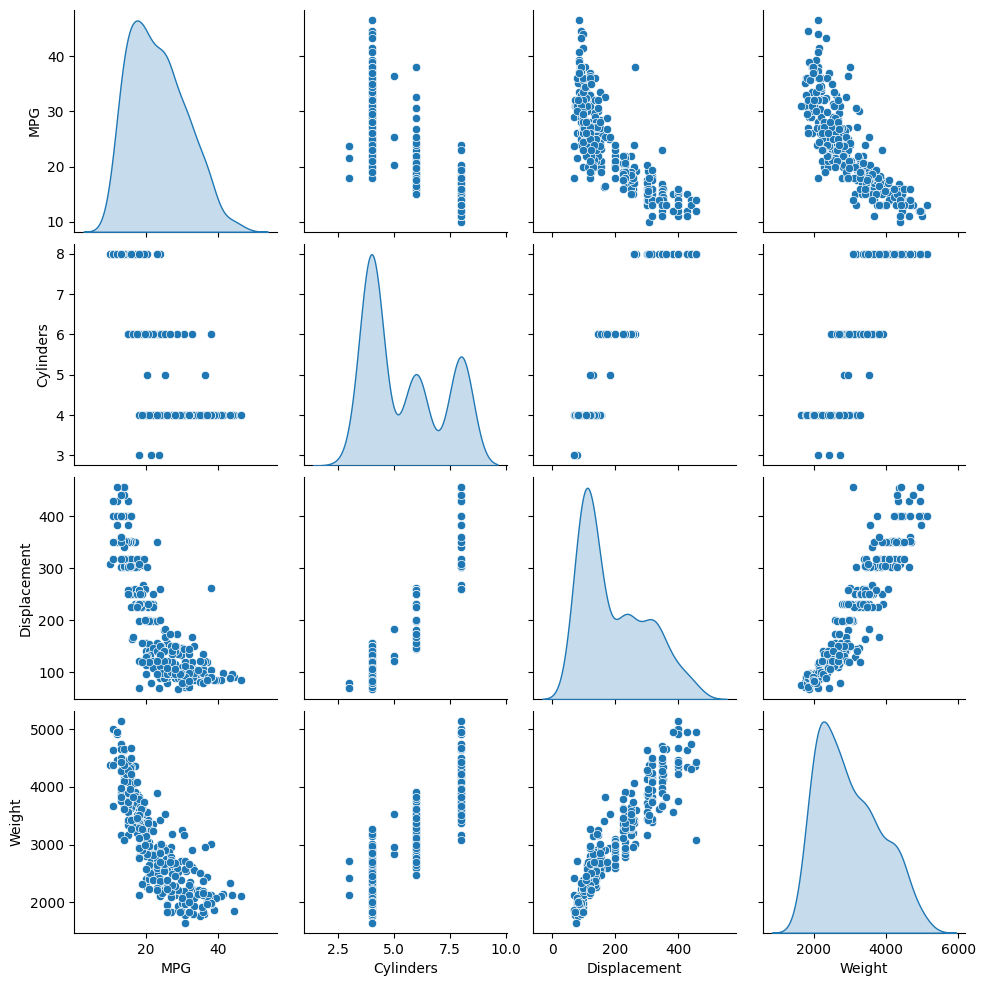

In [ ]:
sns.pairplot(train_dataset[['MPG','Cylinders','Displacement','Weight']],diag_kind='kde')

In [ ]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [8]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

In [9]:
train_dataset.describe().transpose()[['mean','std']]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [10]:
normalizer = tf.keras.layers.Normalization(axis=-1)

In [11]:
normalizer.adapt(np.array(train_features))

In [12]:
print(normalizer.mean.numpy())

[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


In [14]:
first = np.array(train_features[:1])

In [15]:
with np.printoptions(precision=2,suppress=True):
    print(f'pierwszy przypadek: {first}')
    print(f'po normalizacji: {normalizer(first.astype(float)).numpy()}')

pierwszy przypadek: [[4 90.0 75.0 2125.0 14.5 74 False False True]]
po normalizacji: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


In [16]:
#regresja liniowa z jedną zmienną
#y = ax+b

horsepower = np.array(train_features['Horsepower'])
horsepower_normalizer = layers.Normalization(input_shape=[1,],axis=None)
horsepower_normalizer.adapt(horsepower)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [18]:
horsepower_model.predict(horsepower[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[ 0.615],
       [ 0.347],
       [-1.135],
       [ 0.862],
       [ 0.78 ],
       [ 0.306],
       [ 0.924],
       [ 0.78 ],
       [ 0.203],
       [ 0.347]], dtype=float32)

In [19]:
horsepower_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

In [20]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 7.28 s, sys: 259 ms, total: 7.54 s
Wall time: 7.3 s


In [21]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,3.804199,4.197450,95
96,3.803067,4.182409,96
97,3.802343,4.192392,97
98,3.802405,4.183007,98
99,3.803511,4.184422,99


In [22]:
import matplotlib.pyplot as plt

In [23]:
def plot_loss(history):
    plt.plot(history.history['loss'],label='loss')
    plt.plot(history.history['val_loss'],label='val_loss')
    plt.ylim([0,10])
    plt.xlabel('Epoch')
    plt.ylabel('Error[MPG]')
    plt.legend()
    plt.grid(True)

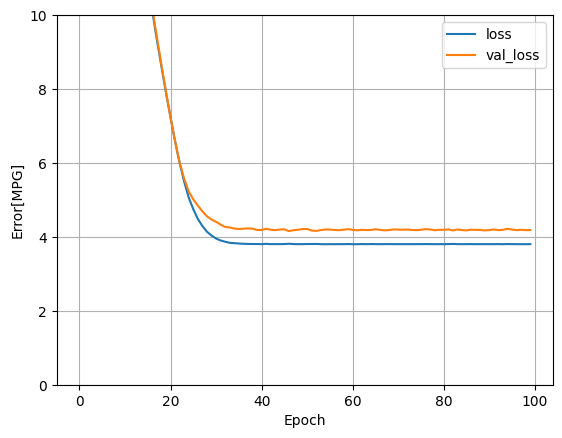

In [24]:
plot_loss(history)

In [25]:
test_result = {}
test_result['horsepower_model'] = horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels,
    verbose=0
)

In [26]:
x = tf.linspace(0.0,250,251)
y = horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [27]:
def plot_horsepower(x,y):
    plt.scatter(train_features['Horsepower'],train_labels,label='Data')
    plt.plot(x,y,color='k',label='Predictions')
    plt.xlabel('Horsepower')
    plt.ylabel('MPG')
    plt.legend()

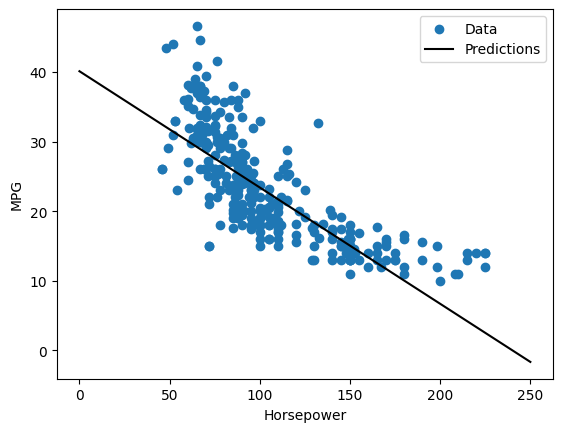

In [28]:
plot_horsepower(x,y)

In [29]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])
linear_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (314, 9)               │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [30]:
linear_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

In [31]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 7.93 s, sys: 295 ms, total: 8.22 s
Wall time: 8.39 s


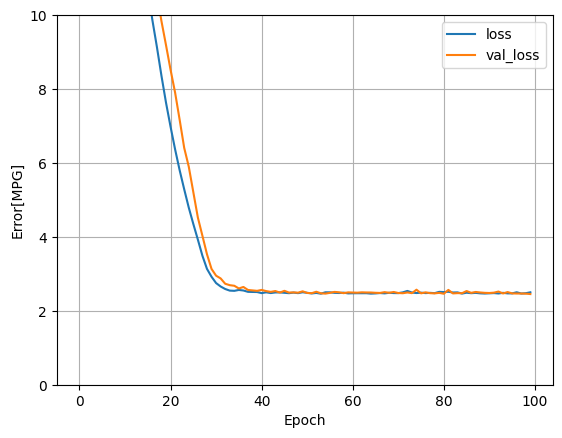

In [32]:
plot_loss(history)

In [34]:
test_result['linear_model'] = linear_model.evaluate(
    test_features,
    test_labels,
    verbose=0
)

In [35]:
#regresja z głędoką siecią neuronową DNN
def build_and_compile(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(64,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(1)
    ])
    model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(0.001))
    return model

In [36]:
#regresja z użyciem DNN i pojedynczego wejścia
dnn_horsepower_model = build_and_compile(horsepower_normalizer)

In [37]:
dnn_horsepower_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

In [38]:
%%time
history = dnn_horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 8.47 s, sys: 336 ms, total: 8.81 s
Wall time: 9 s


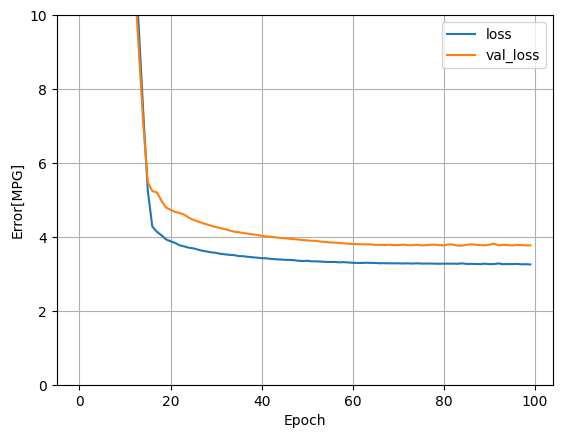

In [39]:
plot_loss(history)

In [40]:
test_result['dnn_horsepower_model'] = dnn_horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels,
    verbose=0
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


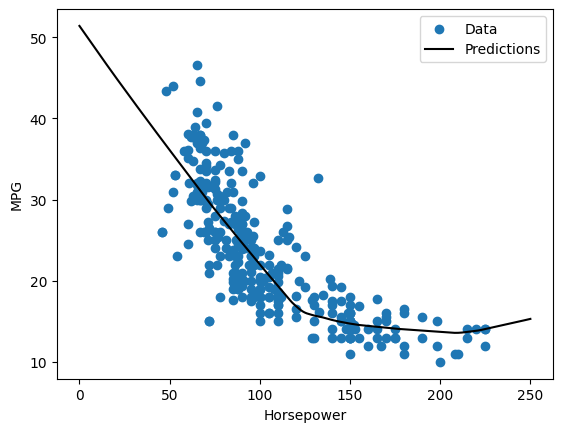

In [41]:
x = tf.linspace(0.0,250,251)
y = dnn_horsepower_model.predict(x)
plot_horsepower(x,y)

In [42]:
#regresja przy użyciu dnn i wielu danych wejściowych
dnn_model = build_and_compile(normalizer)
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [43]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 8.3 s, sys: 300 ms, total: 8.6 s
Wall time: 8.83 s


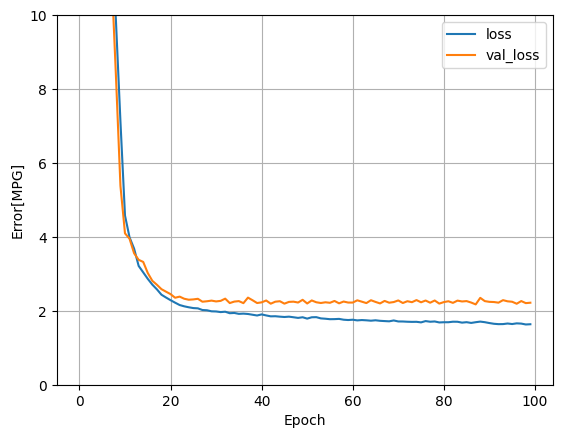

In [44]:
plot_loss(history)

In [46]:
test_result['dnn_model'] = dnn_model.evaluate(
    test_features,
    test_labels,
    verbose=0
)

In [47]:
#regresja z głędoką siecią neuronową DNN
def build_and_compile_biggest(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(128,activation='relu'),
        layers.Dense(512,activation='relu'),
        layers.Dense(512,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(1)
    ])
    model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(0.001))
    return model

In [48]:
#regresja przy użyciu dnn - z większą ilością warstw i wielu danych wejściowych
dnn_model_big = build_and_compile_biggest(normalizer)
dnn_model_big.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [49]:
%%time
history = dnn_model_big.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 13.4 s, sys: 578 ms, total: 14 s
Wall time: 12 s


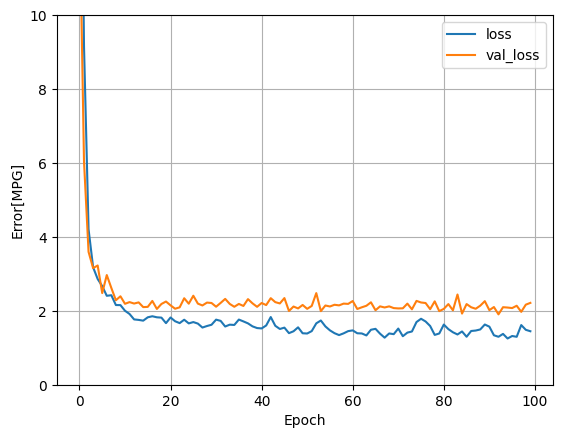

In [ ]:
plot_loss(history)

In [50]:
test_result['dnn_model_big'] = dnn_model_big.evaluate(
    test_features,
    test_labels,
    verbose=0
)

## Tabela zbiorcza wyników

Pełna tabela została przeniesiona za ocenę dodatkowej sieci, dzięki czemu obejmuje również model `dnn_model_optimized`.


# Model dodatkowy: zoptymalizowana sieć neuronowa dla Auto MPG

Największa wcześniejsza sieć nie poprawiła wyniku, ponieważ przy około 300 rekordach treningowych łatwo się przeucza.  
Poniższy model jest **mniejszy, regularizowany i dopasowany do małego zbioru danych tabelarycznych**.

Najważniejsze zmiany:

- dodatkowe cechy opisujące fizyczne relacje między masą, mocą, pojemnością i liczbą cylindrów,
- osobna normalizacja nowych danych wejściowych,
- warstwy `64 → 32 → 16` z aktywacją `swish`,
- funkcja straty Huber, mniej wrażliwa na nietypowe samochody,
- skalowanie wartości wyjściowej MPG,
- `EarlyStopping` i automatyczne zmniejszanie learning rate,
- regularyzacja L2 ograniczająca przeuczenie.


In [ ]:
# Powtarzalność eksperymentu
tf.keras.utils.set_random_seed(42)

def add_engineered_features(features):
    """Tworzy cechy wynikające z relacji fizycznych między parametrami auta."""
    result = features.copy().astype('float32')
    eps = 1e-6

    result['Power_to_weight'] = (
        result['Horsepower'] / (result['Weight'] / 1000.0 + eps)
    )
    result['Weight_per_cylinder'] = (
        result['Weight'] / (result['Cylinders'] + eps)
    )
    result['Displacement_per_cylinder'] = (
        result['Displacement'] / (result['Cylinders'] + eps)
    )
    result['Horsepower_per_cylinder'] = (
        result['Horsepower'] / (result['Cylinders'] + eps)
    )
    result['Vehicle_age_index'] = 82.0 - result['Model Year']
    result['Model_year_squared'] = (result['Model Year'] - 76.0) ** 2
    result['Weight_x_horsepower'] = (
        (result['Weight'] / 1000.0) * (result['Horsepower'] / 100.0)
    )

    return result

train_features_optimized = add_engineered_features(train_features)
test_features_optimized = add_engineered_features(test_features)

print('Liczba pierwotnych cech:', train_features.shape[1])
print('Liczba cech po rozszerzeniu:', train_features_optimized.shape[1])
train_features_optimized.head()


In [ ]:
# Nowa warstwa normalizująca musi zostać dopasowana do rozszerzonego zestawu cech
optimized_normalizer = layers.Normalization(axis=-1)
optimized_normalizer.adapt(
    np.asarray(train_features_optimized, dtype=np.float32)
)

# Skalowanie celu stabilizuje uczenie regresji
target_mean = float(train_labels.mean())
target_std = float(train_labels.std())

print(f'Średnia MPG w zbiorze treningowym: {target_mean:.3f}')
print(f'Odchylenie standardowe MPG: {target_std:.3f}')


In [ ]:
def build_optimized_dnn(normalizer, number_of_features, target_mean, target_std):
    inputs = keras.Input(
        shape=(number_of_features,),
        name='car_parameters'
    )

    x = normalizer(inputs)

    x = layers.Dense(
        64,
        activation='swish',
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense_64'
    )(x)

    x = layers.Dense(
        32,
        activation='swish',
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense_32'
    )(x)

    x = layers.Dense(
        16,
        activation='swish',
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense_16'
    )(x)

    # Sieć najpierw przewiduje wynik w skali standaryzowanej
    standardized_output = layers.Dense(
        1,
        kernel_initializer='zeros',
        bias_initializer='zeros',
        name='standardized_mpg'
    )(x)

    # Powrót do rzeczywistej skali MPG
    mpg_output = layers.Rescaling(
        scale=target_std,
        offset=target_mean,
        name='mpg'
    )(standardized_output)

    model = keras.Model(
        inputs=inputs,
        outputs=mpg_output,
        name='optimized_auto_mpg_dnn'
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.005,
            clipnorm=1.0
        ),
        loss=keras.losses.Huber(delta=1.5),
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse')
        ]
    )

    return model

dnn_model_optimized = build_optimized_dnn(
    optimized_normalizer,
    train_features_optimized.shape[1],
    target_mean,
    target_std
)

dnn_model_optimized.summary()


In [ ]:
optimized_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=50,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae',
        mode='min',
        factor=0.5,
        patience=15,
        min_lr=1e-5,
        verbose=1
    )
]

history_optimized = dnn_model_optimized.fit(
    train_features_optimized,
    train_labels,
    validation_split=0.2,
    epochs=600,
    batch_size=32,
    shuffle=True,
    verbose=0,
    callbacks=optimized_callbacks
)

print('Liczba wykonanych epok:', len(history_optimized.history['loss']))
print(
    'Najlepszy walidacyjny MAE:',
    f"{min(history_optimized.history['val_mae']):.4f} MPG"
)


In [ ]:
# Przebieg uczenia
history_optimized_df = pd.DataFrame(history_optimized.history)

plt.figure(figsize=(10, 5))
plt.plot(history_optimized_df['mae'], label='MAE - trening')
plt.plot(history_optimized_df['val_mae'], label='MAE - walidacja')
plt.xlabel('Epoka')
plt.ylabel('MAE [MPG]')
plt.title('Uczenie zoptymalizowanej sieci DNN')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Ocena na tym samym zbiorze testowym co wcześniejsze modele
optimized_evaluation = dnn_model_optimized.evaluate(
    test_features_optimized,
    test_labels,
    verbose=0,
    return_dict=True
)

optimized_mae = float(optimized_evaluation['mae'])
optimized_rmse = float(optimized_evaluation['rmse'])

test_result['dnn_model_optimized'] = optimized_mae

print(f'MAE zoptymalizowanej sieci:  {optimized_mae:.4f} MPG')
print(f'RMSE zoptymalizowanej sieci: {optimized_rmse:.4f} MPG')


In [ ]:
# Pełna tabela zbiorcza, razem z dodatkową siecią neuronową
# Każdy wynik sprowadzamy do pojedynczej wartości MAE.
def extract_mae(value):
    value_array = np.asarray(value, dtype=float).reshape(-1)
    return float(value_array[0])

results_summary = pd.DataFrame(
    {
        'Model': list(test_result.keys()),
        'Mean absolute Error [MPG]': [
            extract_mae(value) for value in test_result.values()
        ]
    }
).sort_values(
    'Mean absolute Error [MPG]',
    ascending=True
).reset_index(drop=True)

results_summary.insert(
    0,
    'Miejsce',
    np.arange(1, len(results_summary) + 1)
)

previous_results = {
    name: extract_mae(value)
    for name, value in test_result.items()
    if name != 'dnn_model_optimized'
}

best_previous_name = min(previous_results, key=previous_results.get)
best_previous_mae = previous_results[best_previous_name]
improvement_percent = (
    (best_previous_mae - optimized_mae) / best_previous_mae * 100.0
)

print(f'Najlepszy wcześniejszy model: {best_previous_name}')
print(f'Jego MAE: {best_previous_mae:.4f} MPG')
print(f'MAE dodatkowej sieci: {optimized_mae:.4f} MPG')
print(f'Zmiana błędu: {improvement_percent:.2f}%')

results_summary.style.format(
    {'Mean absolute Error [MPG]': '{:.4f}'}
).highlight_min(
    subset=['Mean absolute Error [MPG]']
).hide(axis='index')


In [ ]:
# Predykcje i analiza reszt
optimized_predictions = dnn_model_optimized.predict(
    test_features_optimized,
    verbose=0
).reshape(-1)

optimized_residuals = test_labels.to_numpy() - optimized_predictions

plt.figure(figsize=(7, 7))
plt.scatter(test_labels, optimized_predictions, alpha=0.75)
minimum_value = min(test_labels.min(), optimized_predictions.min())
maximum_value = max(test_labels.max(), optimized_predictions.max())
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle='--'
)
plt.xlabel('Rzeczywiste MPG')
plt.ylabel('Przewidywane MPG')
plt.title('Rzeczywiste i przewidywane spalanie')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(optimized_predictions, optimized_residuals, alpha=0.75)
plt.axhline(0, linestyle='--')
plt.xlabel('Przewidywane MPG')
plt.ylabel('Reszta: wartość rzeczywista - predykcja')
plt.title('Analiza reszt zoptymalizowanej sieci')
plt.grid(True)
plt.show()


## Dlaczego ten model powinien działać lepiej?

Poprzednia bardzo duża sieć miała setki tysięcy parametrów, mimo że zbiór treningowy zawiera tylko około 300 samochodów.  
Taki model łatwo zapamiętuje dane treningowe, ale gorzej generalizuje.

Nowa sieć ma znacznie mniej parametrów i otrzymuje cechy, które bezpośrednio opisują relacje istotne dla spalania. Funkcja Huber ogranicza wpływ przypadków odstających, a `EarlyStopping` zatrzymuje trening w chwili, gdy dalsze uczenie przestaje poprawiać walidacyjny MAE.

Wynik końcowy jest liczony automatycznie na tym samym zbiorze testowym, dlatego porównanie z wcześniejszymi modelami pozostaje uczciwe.
